In [6]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [7]:
os.chdir("/Users/alexanderhannah/Desktop/Github-projects/airr-ml-25")

In [8]:
# This cell is building the vocabulary and input dimensions needed to encode sequences into one-hot vectors

AMINO_ACIDS = sorted(list("ACDEFGHIKLMNPQRSTVWY"))
AA_TO_IDX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
MAX_JUNCTION_LEN = 31

# we'll rebuild v/j vocabularies across all datasets
base = "data/train_datasets/train_datasets"

all_v_calls = set()
all_j_calls = set()

for dataset in range(1, 9):
    meta = pd.read_csv(f"{base}/train_dataset_{dataset}/metadata.csv")
    for filename in meta["filename"].values[:5]:
        seqs = pd.read_csv(f"{base}/train_dataset_{dataset}/{filename}", sep="\t")
        all_v_calls.update(seqs["v_call"].unique())
        all_j_calls.update(seqs["j_call"].unique())

V_CALL_TO_IDX = {v: i for i, v in enumerate(sorted(all_v_calls))}
J_CALL_TO_IDX = {j: i for i, j in enumerate(sorted(all_j_calls))}

INPUT_DIM = MAX_JUNCTION_LEN * len(AMINO_ACIDS) + len(V_CALL_TO_IDX) + len(J_CALL_TO_IDX)
print("Input dimension:", INPUT_DIM)

Input dimension: 788


In [11]:
# Converts a row from a .tsv file into a vector that the neural net can read
# One-hot encodes each of the junction_aa, v_call, and j_call
# Concatenates into one flat vector, length 788
def encode_sequence(junction_aa, v_call, j_call):
    # encode junction_aa
    aa_vector = np.zeros(MAX_JUNCTION_LEN * len(AMINO_ACIDS))
    for i, aa in enumerate(junction_aa[:MAX_JUNCTION_LEN]):
        if aa in AA_TO_IDX:
            aa_vector[i * len(AMINO_ACIDS) + AA_TO_IDX[aa]] = 1.0

    # encode v_call
    v_vector = np.zeros(len(V_CALL_TO_IDX))
    if v_call in V_CALL_TO_IDX:
        v_vector[V_CALL_TO_IDX[v_call]] = 1.0

    # encode j_call
    j_vector = np.zeros(len(J_CALL_TO_IDX))
    if j_call in J_CALL_TO_IDX:
        j_vector[J_CALL_TO_IDX[j_call]] = 1.0

    return np.concatenate([aa_vector, v_vector, j_vector])

# Calls encode_sequence on every row of a repertoire
# Returns a PyTorch tensor of shape [N x 788, where N is number of sequences]
# This is the input to the neural network for one person
def encode_repertoire(filepath):
    seqs = pd.read_csv(filepath, sep="\t")
    encoded = np.array([
        encode_sequence(row.junction_aa, row.v_call, row.j_call)
        for _, row in seqs.iterrows()
    ])
    return torch.tensor(encoded, dtype=torch.float32)

class AttentionMIL. 
  
This is the neural network itself, defined as a PyTorch class. It has three components:  
1) self.encoder.  
A small feedforward network applied to every sequence independently. Takes a 788-dim vector and compresses it to a 128-dim embedding. Think of it as learning a more meaningful, compact representation of each sequence.  
2) self.attention.  
Takes each 128-dim embedding and outputs a single number — the importance score for that sequence. After softmax, these scores sum to 1 across all sequences in the repertoire. High score = this sequence matters more for the classification.  
3) self.forward(x).  
This is what happens during a forward pass — when you feed one person's data through the model:  
  
Encode all sequences → [N × 128].  
Compute attention weights → [N × 1], summing to 1.  
Weighted sum → one [128] vector representing the whole person.  
Classify → one number between 0 and 1 (probability of disease)

In [12]:
class AttentionMIL(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, attention_dim=64):
        super().__init__()
        
        # encoder: compress input vector to hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, hidden_dim)
        )
        
        # attention network: score each sequence
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1)
        )
        
        # classifier: bag vector -> probability
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x shape: [N x input_dim] where N = number of sequences
        
        # encode each sequence
        h = self.encoder(x)           # [N x hidden_dim]
        
        # compute attention weights
        a = self.attention(h)         # [N x 1]
        a = torch.softmax(a, dim=0)   # normalize across sequences
        
        # weighted sum -> bag representation
        z = (a * h).sum(dim=0)        # [hidden_dim]
        
        # classify
        return self.classifier(z)     # scalar probability


# test it
model = AttentionMIL(INPUT_DIM)
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

AttentionMIL(
  (encoder): Sequential(
    (0): Linear(in_features=788, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
Parameters: 243330


In [ ]:
# This is a function to read in a subset of the metadata, half positive, half negative

def load_dataset(dataset_num, sample_frac=0.1, random_state=42):
    base = "data/train_datasets/train_datasets"
    meta = pd.read_csv(f"{base}/train_dataset_{dataset_num}/metadata.csv")
    
    # sample 10% stratified by label
    pos = meta[meta["label_positive"] == True].sample(frac=sample_frac, random_state=random_state)
    neg = meta[meta["label_positive"] == False].sample(frac=sample_frac, random_state=random_state)
    subset = pd.concat([pos, neg]).reset_index(drop=True)
    
    print(f"Dataset {dataset_num}: {len(subset)} repertoires ({len(pos)} positive, {len(neg)} negative)")
    return subset, f"{base}/train_dataset_{dataset_num}"

# test it
subset, path = load_dataset(1, sample_frac=0.2)
print(subset.head())

Dataset 1: 400 repertoires (200 positive, 200 negative)
                      repertoire_id                              filename  \
0  d92d5febe655f292b99bbefbb7949039  d92d5febe655f292b99bbefbb7949039.tsv   
1  1c379d4c42fabedc505d187ed9b20537  1c379d4c42fabedc505d187ed9b20537.tsv   
2  b95c26f9060b017121ae2f363de3e758  b95c26f9060b017121ae2f363de3e758.tsv   
3  a995d49b39c2d8d5455702431c54d3dd  a995d49b39c2d8d5455702431c54d3dd.tsv   
4  77750865ae27635a4cf138ad7637fc87  77750865ae27635a4cf138ad7637fc87.tsv   

   label_positive  
0            True  
1            True  
2            True  
3            True  
4            True  


In [33]:
# split our 40 repertoires into two groups: training and validation

from sklearn.model_selection import train_test_split

train_meta, val_meta = train_test_split(
    subset,
    test_size=0.2,
    stratify=subset["label_positive"],
    random_state=42
)

print(f"Train: {len(train_meta)} repertoires ({train_meta['label_positive'].sum()} positive)")
print(f"Val:   {len(val_meta)} repertoires ({val_meta['label_positive'].sum()} positive)")

Train: 320 repertoires (160 positive)
Val:   80 repertoires (40 positive)


In [34]:
# Cell 10 - Pre-encode all repertoires
import time

def preload_dataset(meta, path):
    repertoires = []
    labels = []
    
    print("Pre-encoding repertoires...")
    for i, (_, row) in enumerate(meta.iterrows()):
        filepath = f"{path}/{row['filename']}"
        x = encode_repertoire(filepath)
        repertoires.append(x)
        labels.append(float(row["label_positive"]))
        if (i + 1) % 5 == 0:
            print(f"  {i+1}/{len(meta)} done")
    
    return repertoires, labels

start = time.time()
train_repertoires, train_labels = preload_dataset(train_meta, path)
val_repertoires, val_labels = preload_dataset(val_meta, path)
print(f"Done in {time.time() - start:.1f}s")

Pre-encoding repertoires...
  5/320 done
  10/320 done
  15/320 done
  20/320 done
  25/320 done
  30/320 done
  35/320 done
  40/320 done
  45/320 done
  50/320 done
  55/320 done
  60/320 done
  65/320 done
  70/320 done
  75/320 done
  80/320 done
  85/320 done
  90/320 done
  95/320 done
  100/320 done
  105/320 done
  110/320 done
  115/320 done
  120/320 done
  125/320 done
  130/320 done
  135/320 done
  140/320 done
  145/320 done
  150/320 done
  155/320 done
  160/320 done
  165/320 done
  170/320 done
  175/320 done
  180/320 done
  185/320 done
  190/320 done
  195/320 done
  200/320 done
  205/320 done
  210/320 done
  215/320 done
  220/320 done
  225/320 done
  230/320 done
  235/320 done
  240/320 done
  245/320 done
  250/320 done
  255/320 done
  260/320 done
  265/320 done
  270/320 done
  275/320 done
  280/320 done
  285/320 done
  290/320 done
  295/320 done
  300/320 done
  305/320 done
  310/320 done
  315/320 done
  320/320 done
Pre-encoding repertoires...
  5/

In [35]:
def train_model_preloaded(model, repertoires, labels, n_epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCELoss()
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        
        for x, y in zip(repertoires, labels):
            y_tensor = torch.tensor([y], dtype=torch.float32)
            
            optimizer.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y_tensor)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(repertoires)
        print(f"Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.4f}")
    
    return model

In [36]:
def evaluate_model_preloaded(model, repertoires, labels):
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for x in repertoires:
            pred = model(x).item()
            predictions.append(pred)
    
    return labels, predictions

In [37]:
model = AttentionMIL(INPUT_DIM)
model = train_model_preloaded(model, train_repertoires, train_labels, n_epochs=20)

true_labels, predictions = evaluate_model_preloaded(model, val_repertoires, val_labels)
print("True labels: ", true_labels)
print("Predictions:", [round(p, 3) for p in predictions])

Epoch 1/20 — Loss: 0.6963
Epoch 2/20 — Loss: 0.6946
Epoch 3/20 — Loss: 0.6944
Epoch 4/20 — Loss: 0.6942
Epoch 5/20 — Loss: 0.6941
Epoch 6/20 — Loss: 0.6940
Epoch 7/20 — Loss: 0.6939
Epoch 8/20 — Loss: 0.6939
Epoch 9/20 — Loss: 0.6938
Epoch 10/20 — Loss: 0.6976
Epoch 11/20 — Loss: 0.6428
Epoch 12/20 — Loss: 0.5058
Epoch 13/20 — Loss: 0.3410
Epoch 14/20 — Loss: 0.3041
Epoch 15/20 — Loss: 0.2124
Epoch 16/20 — Loss: 0.1700
Epoch 17/20 — Loss: 0.1540
Epoch 18/20 — Loss: 0.1936
Epoch 19/20 — Loss: 0.0753
Epoch 20/20 — Loss: 0.0555
True labels:  [0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
Predictions: [0.128, 0.985, 0.0, 0.096, 0.047, 0.982, 

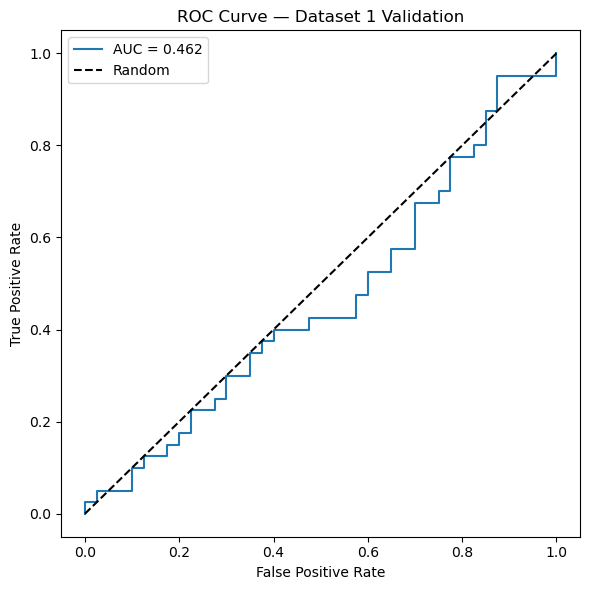

AUC: 0.462


In [38]:
fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Dataset 1 Validation")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.3f}")